# PyFC: Handling Joint/Simplex-Constrained Parameters

`bounds_list` (built automatically from your `grids`) only expresses **independent per-parameter box constraints** -- each parameter must lie in `[lo_i, hi_i]`, with no notion of a relationship between two different parameters. Neither `L-BFGS-B`/`SLSQP` (SciPy) nor UltraNest's prior transform have any native concept of a *joint* constraint, such as a **simplex** (`a + b <= 1`).

This notebook was motivated by exactly that gap, which bit a downstream project (an unrelated ultra-high-energy neutrino analysis pipeline) that needed to fit **neutrino flavor fractions** $f_e$, $f_\mu$, $f_\tau$ subject to the physical constraint

$$f_e + f_\mu + f_\tau = 1,\quad f_e, f_\mu, f_\tau \geq 0$$

i.e. $(f_e, f_\mu, f_\tau)$ live on the standard 2-simplex. Their initial workaround -- a hand-rolled smooth logistic penalty multiplying the rate function -- was fragile to tune and, when the penalty was too narrow, caused unstable, non-monotonic profile-likelihood curves.

We'll cover, using a toy version of that exact flavor-fraction scenario:

1. **The problem**: reproduce the failure mode -- a gradient-based optimizer getting stuck at its starting guess when the search box isn't physical.
2. **Mechanism 1 -- `bounds_func`**: tighten a free parameter's box bound based on whichever parameter the scan currently has fixed. This *is* the simplex-constraint example.
3. **Mechanism 2 -- `constraints`**: a `scipy.optimize.LinearConstraint`, for the case `bounds_func` cannot express -- two parameters that are simultaneously free.
4. **Full pipeline**: a real `compute_fc_intervals` run producing an actual 2D Feldman-Cousins confidence region for $(f_e, f_\mu)$, visually confined to the physical simplex.
5. **Bonus**: a `NonlinearConstraint` example (a "sphere" constraint), showing the mechanism isn't limited to linear inequalities.

See the README section *"Handling Joint/Simplex-Constrained Parameters"* and the `optimizers.py` module docstring for the reference documentation this notebook walks through hands-on.

> **Requires an unreleased PyFC feature set.** `bounds_func` and `constraints` are
> new additions and may not be in whichever PyFC version is currently `pip`-installed
> in your kernel. If the imports below succeed but a later cell raises
> `TypeError: ... got an unexpected keyword argument 'bounds_func'`, install this
> branch in editable mode first (from the repository root): `pip install -e .`

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from numba import njit
from scipy.optimize import LinearConstraint, NonlinearConstraint

from pyfc import compute_fc_intervals, generate_corner_plot
from pyfc.optimizers import conditional_fit_1d_scipy, unconditional_fit_scipy

np.random.seed(20260727)

N_TOYS = 30     # Kept small so this notebook runs quickly; use >=500 for real analyses.
CORES = 4

Numba detected: JIT compilation enabled for maximum speed.


## 0. A toy 3-parameter flavor-fraction model

We model a small binned "detector" with 5 bins, where each neutrino flavor hypothesis ($e$, $\mu$, $\tau$) leaves a different expected signature (loosely inspired by how electromagnetic vs. hadronic shower content shapes the radio-detected Askaryan signal differently across flavors). Our 3 fit parameters are:

* `params[0]` = $f_e$ -- electron-flavor fraction
* `params[1]` = $f_\mu$ -- muon-flavor fraction
* `params[2]` = `norm` -- an overall flux normalization (nuisance parameter)

The tau fraction is **derived**, not an independent fit parameter: $f_\tau = 1 - f_e - f_\mu$. That derived quantity must stay non-negative, i.e. $f_e + f_\mu \leq 1$ -- our joint/simplex constraint.

In [2]:
# Fixed "detection efficiency" templates for the three flavor hypotheses, across 5 bins.
TEMPLATE_E   = np.array([5.0, 4.0, 2.0, 1.0, 0.5])
TEMPLATE_MU  = np.array([1.0, 2.0, 3.0, 3.5, 3.0])
TEMPLATE_TAU = np.array([2.0, 2.5, 2.5, 2.0, 1.5])   # referenced as a frozen global inside @njit functions below

BOUNDS_3P = [(0.0, 1.0), (0.0, 1.0), (0.5, 2.0)]   # f_e, f_mu, norm
PARAM_NAMES_3P = ["f_e", "f_mu", "norm"]

ZERO_SUMW2 = np.zeros_like(TEMPLATE_E)

# Mock "observed" data generated from a physical point deep inside the simplex.
TRUE_F_E, TRUE_F_MU, TRUE_NORM = 0.5, 0.3, 1.0
TRUE_F_TAU = 1.0 - TRUE_F_E - TRUE_F_MU
mu_true_3p = TRUE_NORM * (TRUE_F_E * TEMPLATE_E + TRUE_F_MU * TEMPLATE_MU + TRUE_F_TAU * TEMPLATE_TAU)
N_OBS_3P = np.random.poisson(mu_true_3p)
print("Mock observed counts:", N_OBS_3P)

Mock observed counts: [3 2 0 1 2]


## 1. The problem: a flat-gradient trap without constraint handling

To make the failure mode concrete, our first `compute_rates_func` uses a **hard cutoff**: if $f_e + f_\mu > 1$, it returns a rate of exactly zero everywhere, with no dependence on *how far* past the boundary the point is.

Even with PyFC's own smoothing of `calc_nll`'s unphysical-rate penalty (a separate, already-applied fix for a flat *constant* NLL as a function of $\mu$), a rate function like this one is still **discontinuous in the fit parameters**: $\mu$ jumps to a fixed value of exactly zero the instant the constraint is violated, and stays exactly zero no matter how far past the boundary you go. No amount of smoothing calc_nll's response *to* $\mu$ can recover information that was never there between the parameters and $\mu$ in the first place -- which is exactly why `bounds_func`/`constraints` (which keep the optimizer from ever entering that region) remain necessary regardless.

In [3]:
@njit(fastmath=True, nogil=True)
def compute_rates_hard_cutoff(params, S_sumw2, B_sumw2):
    f_e, f_mu, norm = params[0], params[1], params[2]
    if f_e + f_mu > 1.0:
        return np.zeros_like(TEMPLATE_E), S_sumw2
    f_tau = 1.0 - f_e - f_mu
    mu = norm * (f_e * TEMPLATE_E + f_mu * TEMPLATE_MU + f_tau * TEMPLATE_TAU)
    return mu, S_sumw2


# Profile f_e across a grid, letting (f_mu, norm) float free -- with NO bounds_func.
# The default starting guess for the free parameters is always their own bounds
# midpoint: f_mu starts at 0.5 and norm at 1.25, regardless of the fixed f_e value.
f_e_grid = np.linspace(0.3, 0.9, 7)
print(f"{'f_e (fixed)':>12} | {'f_mu (profiled)':>16} | {'f_e+f_mu':>9} | {'NLL':>10}")
print("-" * 58)
for f_e_test in f_e_grid:
    nll, best_p = conditional_fit_1d_scipy(
        f_e_test, 0, 3, N_OBS_3P, BOUNDS_3P,
        compute_rates_hard_cutoff, S_sumw2=ZERO_SUMW2, B_sumw2=ZERO_SUMW2,
    )
    print(f"{f_e_test:12.3f} | {best_p[1]:16.6f} | {f_e_test + best_p[1]:9.3f} | {nll:10.3f}")


 f_e (fixed) |  f_mu (profiled) |  f_e+f_mu |        NLL
----------------------------------------------------------


       0.300 |         0.164089 |     0.464 |      4.783
       0.400 |         0.280728 |     0.681 |      4.585
       0.500 |         0.588801 |     1.089 |    438.233
       0.600 |         0.500000 |     1.100 |    438.233
       0.700 |         0.500000 |     1.200 |    438.233
       0.800 |         0.500000 |     1.300 |    438.233
       0.900 |         0.500000 |     1.400 |    438.233


Notice that for every `f_e (fixed)` value above 0.5, `f_mu (profiled)` comes back **exactly 0.5** -- the untouched bounds midpoint. The optimizer's starting guess landed in the unphysical region (`f_e + f_mu > 1`), the rate function pinned $\mu$ to a fixed zero, `calc_nll` saw zero gradient, and L-BFGS-B reported "converged" without ever having moved. This is precisely the failure mode reported by the downstream project: profiled nuisance parameters sitting exactly at their starting guess across a wide swath of grid points.

## 2. Mechanism 1: `bounds_func` -- for a constraint on the currently-fixed parameter

`bounds_func` tightens a *free* parameter's own box bound based on whichever parameter the scan currently has fixed. Since $f_e$ is fixed during this 1D scan, we can tighten $f_\mu$'s bound to $[0,\, 1 - f_{e,\text{test}}]$ -- the box itself becomes physical, so the optimizer's bounds-midpoint starting guess can never land in forbidden territory again.

This is literally an instance of the **simplex constraint**: $(f_e, f_\mu, f_\tau)$ live on the standard 2-simplex $f_e + f_\mu + f_\tau = 1,\ f_e, f_\mu, f_\tau \geq 0$, and `simplex_bounds_func` below enforces the $f_e + f_\mu \leq 1$ face of it directly on the search box.

In [4]:
def simplex_bounds_func(fixed_values, free_indices, default_bounds_list):
    '''f_e (index 0) + f_mu (index 1) <= 1, i.e. keeps (f_e, f_mu, f_tau) on the simplex.'''
    bounds = [default_bounds_list[i] for i in free_indices]
    if 0 in fixed_values and 1 in free_indices:        # f_e fixed, f_mu free
        j = free_indices.index(1)
        lo, hi = bounds[j]
        bounds[j] = (lo, min(hi, 1.0 - fixed_values[0]))
    if 1 in fixed_values and 0 in free_indices:         # f_mu fixed, f_e free
        j = free_indices.index(0)
        lo, hi = bounds[j]
        bounds[j] = (lo, min(hi, 1.0 - fixed_values[1]))
    return bounds


# Same hard-cutoff rate function as Section 1 -- bounds_func fixes the problem by
# keeping the optimizer out of the unphysical region entirely, sidestepping the
# discontinuity rather than needing to smooth through it.
print(f"{'f_e (fixed)':>12} | {'f_mu (profiled)':>16} | {'f_e+f_mu':>9} | {'NLL':>10}")
print("-" * 58)
for f_e_test in f_e_grid:
    nll, best_p = conditional_fit_1d_scipy(
        f_e_test, 0, 3, N_OBS_3P, BOUNDS_3P,
        compute_rates_hard_cutoff, S_sumw2=ZERO_SUMW2, B_sumw2=ZERO_SUMW2,
        bounds_func=simplex_bounds_func,
    )
    print(f"{f_e_test:12.3f} | {best_p[1]:16.6f} | {f_e_test + best_p[1]:9.3f} | {nll:10.3f}")


 f_e (fixed) |  f_mu (profiled) |  f_e+f_mu |        NLL
----------------------------------------------------------
       0.300 |         0.164089 |     0.464 |      4.783
       0.400 |         0.280729 |     0.681 |      4.585
       0.500 |         0.397060 |     0.897 |      4.406
       0.600 |         0.400000 |     1.000 |      4.274
       0.700 |         0.300000 |     1.000 |      4.361
       0.800 |         0.200000 |     1.000 |      4.732
       0.900 |         0.100000 |     1.000 |      5.486


`f_mu (profiled)` now varies smoothly with `f_e (fixed)` and always satisfies `f_e + f_mu <= 1` (up to floating-point tolerance) -- the fit is finding real, physically distinct optima instead of getting stuck. No penalty function was needed at all.

## 3. Mechanism 2: `constraints` -- for two *simultaneously-free* parameters

`bounds_func` only helps when the constraint couples the scan's currently-*fixed* test parameter to a free one. But what if the scan fixes `norm` instead, and profiles $f_e$ **and** $f_\mu$ *together*, as two simultaneously-free nuisance parameters? Neither is ever the fixed test parameter in this scan direction, so `bounds_func` has no way to express the coupling between them.

To make the point clearly, we switch to a rate function that does **not** hard-cutoff -- it extrapolates smoothly through the unphysical region (so there's no gradient-trap issue here; this is purely about the *validity* of the converged answer). We also construct a deliberately extreme mock dataset that pulls the unconstrained fit past the simplex boundary, to make sure the effect is visible.

In [5]:
@njit(fastmath=True, nogil=True)
def compute_rates_smooth(params, S_sumw2, B_sumw2):
    f_e, f_mu, norm = params[0], params[1], params[2]
    f_tau = 1.0 - f_e - f_mu   # NOT clipped -- can go negative; the model just keeps extrapolating.
    mu = norm * (f_e * TEMPLATE_E + f_mu * TEMPLATE_MU + f_tau * TEMPLATE_TAU)
    return mu, S_sumw2


# A deliberately "data-hungry" mock dataset -- built to demonstrate the failure mode,
# not a realistic physics scenario -- that pulls both f_e and f_mu toward their
# individual upper bounds (1.0 each) with nothing to stop their sum from exceeding 1.
N_OBS_EXTREME = np.array([40, 35, 30, 25, 20])

norm_test = 1.0
free_indices_3p = [0, 1]   # f_e, f_mu free; norm (index 2) fixed

print("--- WITHOUT constraints ---")
nll_unc, best_p_unc = conditional_fit_1d_scipy(
    norm_test, 2, 3, N_OBS_EXTREME, BOUNDS_3P,
    compute_rates_smooth, S_sumw2=ZERO_SUMW2, B_sumw2=ZERO_SUMW2,
)
print(f"f_e={best_p_unc[0]:.4f}, f_mu={best_p_unc[1]:.4f}, f_e+f_mu={best_p_unc[0]+best_p_unc[1]:.4f}"
      f"  (physical iff <= 1)")

print("\n--- WITH constraints=[LinearConstraint(f_e + f_mu <= 1)] ---")
# Expressed in the FULL 3-parameter space: 1*f_e + 1*f_mu + 0*norm <= 1.
simplex_constraint = LinearConstraint(A=[[1.0, 1.0, 0.0]], lb=-np.inf, ub=1.0)
nll_con, best_p_con = conditional_fit_1d_scipy(
    norm_test, 2, 3, N_OBS_EXTREME, BOUNDS_3P,
    compute_rates_smooth, S_sumw2=ZERO_SUMW2, B_sumw2=ZERO_SUMW2,
    constraints=[simplex_constraint],
)
print(f"f_e={best_p_con[0]:.4f}, f_mu={best_p_con[1]:.4f}, f_e+f_mu={best_p_con[0]+best_p_con[1]:.4f}"
      f"  (physical iff <= 1)")


--- WITHOUT constraints ---


f_e=1.0000, f_mu=1.0000, f_e+f_mu=2.0000  (physical iff <= 1)

--- WITH constraints=[LinearConstraint(f_e + f_mu <= 1)] ---
f_e=0.5509, f_mu=0.4491, f_e+f_mu=1.0000  (physical iff <= 1)


Without `constraints`, nothing stops $f_e$ and $f_\mu$ from independently pushing toward their own upper bounds -- the converged best-fit point can land with $f_e + f_\mu > 1$ (an unphysical, negative $f_\tau$), even though the fit itself converged cleanly (`res.success = True`) and the NLL surface was perfectly smooth throughout. Supplying `constraints` (which switches the SciPy method from `L-BFGS-B` to `SLSQP` automatically) keeps the *result* on the simplex.

## 4. Full pipeline: a real 2D Feldman-Cousins region for $(f_e, f_\mu)$

Now let's run the actual `compute_fc_intervals` pipeline (not just a single optimizer call) with `bounds_func` supplied, to get real 1D and 2D confidence intervals -- and see the resulting 2D region visually confined to the simplex. For clarity, we fix `norm = 1.0` as a constant here (2 free parameters: $f_e$, $f_\mu$), so the only 2D pair PyFC scans is exactly the one we care about.

Best fit (f_e, f_mu): [0.49999998 0.29999997]


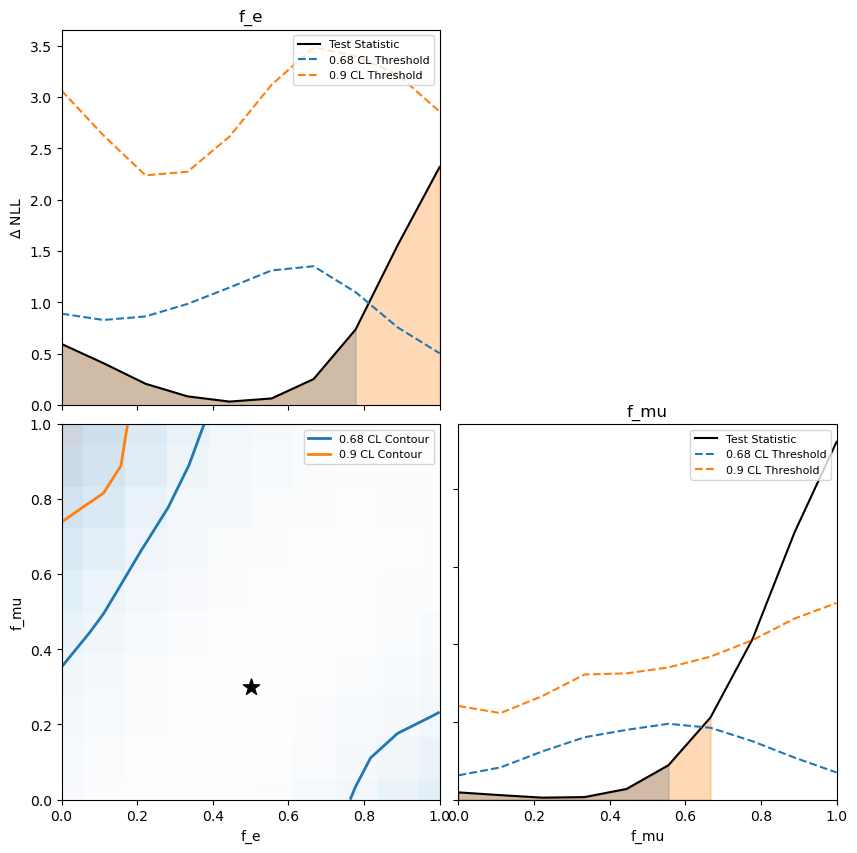

In [6]:
NORM_FIXED = 1.0

@njit(fastmath=True, nogil=True)
def compute_rates_2p(params, S_sumw2, B_sumw2):
    f_e, f_mu = params[0], params[1]
    f_tau = 1.0 - f_e - f_mu
    mu = NORM_FIXED * (f_e * TEMPLATE_E + f_mu * TEMPLATE_MU + f_tau * TEMPLATE_TAU)
    return mu, S_sumw2


def simplex_bounds_func_2p(fixed_values, free_indices, default_bounds_list):
    '''Same simplex constraint as Section 2, adapted to the 2-parameter (f_e, f_mu) model.'''
    bounds = [default_bounds_list[i] for i in free_indices]
    if 0 in fixed_values and 1 in free_indices:
        j = free_indices.index(1)
        lo, hi = bounds[j]
        bounds[j] = (lo, min(hi, 1.0 - fixed_values[0]))
    if 1 in fixed_values and 0 in free_indices:
        j = free_indices.index(0)
        lo, hi = bounds[j]
        bounds[j] = (lo, min(hi, 1.0 - fixed_values[1]))
    return bounds


grids_2p = [np.linspace(0.0, 1.0, 10), np.linspace(0.0, 1.0, 10)]
bounds_list_2p = [(0.0, 1.0), (0.0, 1.0)]

mu_true_2p = NORM_FIXED * (TRUE_F_E * TEMPLATE_E + TRUE_F_MU * TEMPLATE_MU + TRUE_F_TAU * TEMPLATE_TAU)
# Use the Asimov dataset (data == exact expectation, no Poisson noise) so the
# recovered best fit cleanly matches the true value for this illustration --
# with only 5 bins, a single noisy draw can land the MLE near a simplex edge
# just from statistical fluctuation, which would muddy the plot below.
N_OBS_2P = mu_true_2p

results_2p, fig_2p = compute_fc_intervals(
    data=N_OBS_2P,
    grids=grids_2p,
    compute_rates_func=compute_rates_2p,
    bounds_func=simplex_bounds_func_2p,
    likelihood_type="binned",
    cl=[0.68, 0.90],
    n_toys=N_TOYS,
    num_cores=CORES,
    verbose=0,
    sparsify_grid=False,
    warm_start=False,
    output_file="fc_results",
    save_directory="joint_constraints_output/simplex_2p",
    param_names=["f_e", "f_mu"],
    compute_1D_intervals=True,
    compute_2D_intervals=True,
)

print("Best fit (f_e, f_mu):", results_2p["best_fit"])


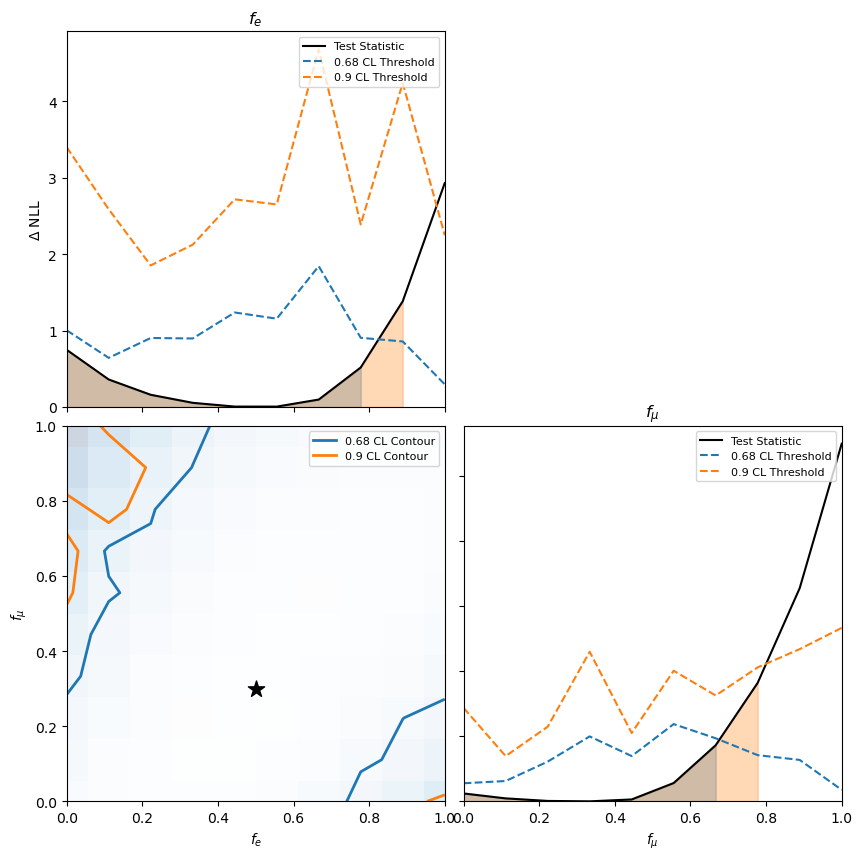

In [7]:
# The built-in corner plot (1D profiles + 2D contour) --
_ = generate_corner_plot(results_2p, {
    "n_params": 2,
    "compute_1D_intervals": True,
    "compute_2D_intervals": True,
    "param_names": [r"$f_e$", r"$f_\mu$"],
    "cl": [0.68, 0.90],
    "save_directory": "joint_constraints_output/simplex_2p",
})
plt.show()

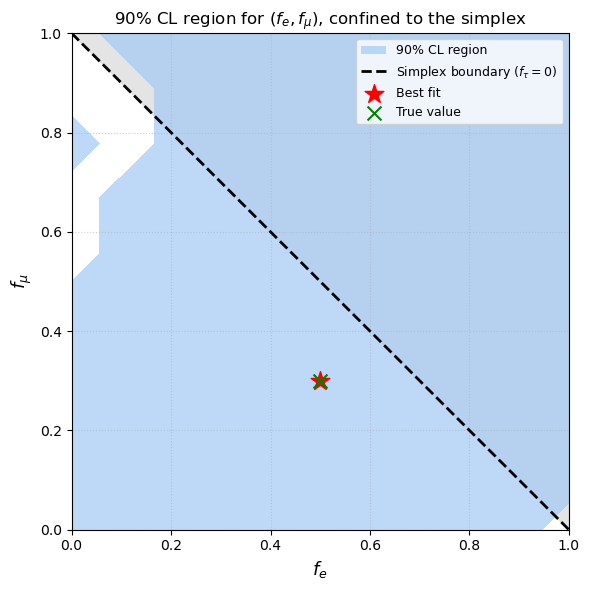

In [8]:
# A bespoke plot overlaying the simplex boundary (f_e + f_mu = 1, i.e. f_tau = 0),
# to make the physical picture explicit: the accepted region can never cross it.
f_e_vals = results_2p["2d_test_p1_p1p2"]
f_mu_vals = results_2p["2d_test_p2_p1p2"]
accepted_90 = results_2p["2d_accepted_p1p2"][0.90]
X, Y = np.meshgrid(f_e_vals, f_mu_vals, indexing="ij")

fig, ax = plt.subplots(figsize=(6, 6))
ax.contourf(X, Y, accepted_90, levels=[0.5, 1.5], colors=["#a1c9f4"], alpha=0.7)
region_proxy = plt.Rectangle((0, 0), 1, 1, fc="#a1c9f4", alpha=0.7, label="90% CL region")  # contourf doesn't support a legend `label` kwarg directly
ax.plot([0, 1], [1, 0], "k--", linewidth=2, label=r"Simplex boundary ($f_\tau = 0$)")
ax.fill_between([0, 1], [1, 0], [1, 1], color="lightgray", alpha=0.6, zorder=0)
ax.scatter(*results_2p["best_fit"], color="red", marker="*", s=200, zorder=5, label="Best fit")
ax.scatter([TRUE_F_E], [TRUE_F_MU], color="green", marker="x", s=100, zorder=5, label="True value")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel(r"$f_e$", fontsize=13)
ax.set_ylabel(r"$f_\mu$", fontsize=13)
ax.set_title("90% CL region for $(f_e, f_\\mu)$, confined to the simplex")
handles, labels = ax.get_legend_handles_labels()
ax.legend([region_proxy] + handles, ["90% CL region"] + labels, loc="upper right", fontsize=9)
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

The shaded 90% CL region never crosses the dashed simplex boundary ($f_\tau = 0$, gray region above it is unphysical, $f_\tau < 0$) -- `bounds_func` kept every single grid point's fit inside the physical triangle, with no user-side penalty function required.

## 5. Bonus: `NonlinearConstraint` -- constraints aren't limited to linear inequalities

Both mechanisms above used a **linear** simplex constraint, but `constraints` also accepts `scipy.optimize.NonlinearConstraint`. As a quick illustration (unrelated to the flavor-fraction model above), consider two generic parameters $a, b$ confined to the unit disk: $a^2 + b^2 \leq 1$.

In [9]:
disk_S = np.array([1.0, 1.0, 1.0])
disk_B = np.array([1.0, 1.0, 1.0])

@njit(fastmath=True, nogil=True)
def compute_rates_disk_demo(params, S_sumw2, B_sumw2):
    a, b = params[0], params[1]
    mu = (2.0 + a) * disk_S + (2.0 + b) * disk_B   # some generic smooth model
    return mu, S_sumw2


disk_bounds = [(-1.5, 1.5), (-1.5, 1.5)]
disk_data = np.array([12.0, 10.0, 8.0])
disk_sigma2 = np.zeros_like(disk_S)

disk_constraint = NonlinearConstraint(lambda p: np.array([p[0]**2 + p[1]**2]), lb=-np.inf, ub=1.0)

nll, best_p = unconditional_fit_scipy(
    disk_data, 2, disk_bounds, compute_rates_disk_demo,
    S_sumw2=disk_sigma2, B_sumw2=disk_sigma2,
    constraints=[disk_constraint],
)
print(f"a={best_p[0]:.4f}, b={best_p[1]:.4f}, a^2+b^2={best_p[0]**2 + best_p[1]**2:.4f}  (physical iff <= 1)")


a=0.7071, b=0.7071, a^2+b^2=1.0000  (physical iff <= 1)


The converged point respects $a^2 + b^2 \leq 1$, using the exact same `constraints=[...]` mechanism as the linear simplex example above -- just with a `NonlinearConstraint` in place of a `LinearConstraint`.

## Summary: which mechanism should I use?

| | `bounds_func` | `constraints` |
|---|---|---|
| **Use when** | The constraint only couples the scan's currently-**fixed** test parameter(s) to a free nuisance parameter | The constraint couples multiple **simultaneously-free** nuisance parameters |
| **Cost** | Cheapest -- tightens the search box itself, so the optimizer never evaluates near the boundary at all | Small overhead (switches SciPy from `L-BFGS-B` to `SLSQP`) |
| **Constraint types** | Anything expressible as a box bound on one free parameter | Linear (`LinearConstraint`) or nonlinear (`NonlinearConstraint`), among any subset of parameters |
| **UltraNest support** | Yes (tightens the prior transform) | Yes (violated points get a very large negative log-likelihood) |

The two mechanisms **compose** -- pass both if your model has constraints of both shapes.

See the README section *"Handling Joint/Simplex-Constrained Parameters"*, the Sphinx docs' Methodology page, and the `optimizers.py` module docstring for further reference.